# Interview Question： Medicare Chronic Conditions Cost Analysis

### 1. Raw requirement

The task at hand is to perform an **exploratory data analysis** (EDA) on publicly available claim data for **Medicare** members in the US. **Medicare is the government healthcare program for US citizens aged 65+.**

The aim is to understand how the cost of treating **certain chronic** conditions varies across different providers.

### 2. Tech key terms
**2.1 Basic task**: exploratory data analysis to understand how the cost of treating certain chronic coditions;

**2.2 Object**: Medicare members >= 65;

**2.3 Granularity**: Provider level; Providers

**2.4 Term Definition**: Medicare is the government healthcare program for US citizens aged 65+;

**2.5 Target Location**: US

**2.6 Timeline**:

| Phase                         | Dates             | Tasks                                                                 |
|-------------------------------|-------------------|----------------------------------------------------------------------|
| Data Collection & Understanding | Day 1 (April 26)   | - Download datasets<br>- Read data dictionaries and understand structure |
| Data Cleaning & Integration     | Day 1-2 (April 26-27) | - Merge chronic conditions into a single column<br>- Join beneficiary and claims data |
| Exploratory Data Analysis (EDA) | Day 2 (April 27)   | - Race distribution<br>- Chronic condition distribution<br>- Cost analysis |
| Benchmarking Providers          | Day 2-3 (April 27-28) | - Calculate cost per provider<br>- Visualize cost distributions<br>- Identify consistently expensive providers |
| Final Output & Report           | Day 3 (April 28)   | - Prepare final Jupyter Notebook<br>- Create summary slides<br>- Submit all materials |






### 3. Data Collection & Investigation

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
outpatient_path = "/content/drive/MyDrive/interview_question/DE1_0_2008_to_2010_Outpatient_Claims_Sample_20.csv"
beneficiary_path = "/content/drive/MyDrive/interview_question/DE1_0_2009_Beneficiary_Summary_File_Sample_20.csv"


outpatient_df = pd.read_csv(outpatient_path)
beneficiary_df = pd.read_csv(beneficiary_path)


<ipython-input-13-1e897aa58310>:10: DtypeWarning: Columns (21,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  outpatient_df = pd.read_csv(outpatient_path)


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# Breifly investigate the dataframe

# print(outpatient_df.head())
# print(beneficiary_df.head()) # SP_ALZHDMTA  SP_CHF  SP_CHRNKIDN  SP_CNCR  SP_COPD  SP_DEPRESSN  SP_DIABETES  SP_ISCHMCHT  SP_OSTEOPRS  SP_RA_OA  SP_STRKETIA
print(beneficiary_df[beneficiary_df["DESYNPUF_ID"] == "000002F7E0A96C32"])


        DESYNPUF_ID  BENE_BIRTH_DT  BENE_DEATH_DT  BENE_SEX_IDENT_CD  \
0  000002F7E0A96C32       19190701            NaN                  2   

   BENE_RACE_CD BENE_ESRD_IND  SP_STATE_CODE  BENE_COUNTY_CD  \
0             2             0              5             400   

   BENE_HI_CVRAGE_TOT_MONS  BENE_SMI_CVRAGE_TOT_MONS  \
0                        0                         0   

   BENE_HMO_CVRAGE_TOT_MONS  PLAN_CVRG_MOS_NUM  SP_ALZHDMTA  SP_CHF  \
0                         0                  0            2       2   

   SP_CHRNKIDN  SP_CNCR  SP_COPD  SP_DEPRESSN  SP_DIABETES  SP_ISCHMCHT  \
0            2        2        2            2            2            2   

   SP_OSTEOPRS  SP_RA_OA  SP_STRKETIA  MEDREIMB_IP  BENRES_IP  PPPYMT_IP  \
0            2         2            2          0.0        0.0        0.0   

   MEDREIMB_OP  BENRES_OP  PPPYMT_OP  MEDREIMB_CAR  BENRES_CAR  PPPYMT_CAR  
0          0.0        0.0        0.0           0.0         0.0         0.0  


In [60]:
print(outpatient_df.head())

        DESYNPUF_ID           CLM_ID  SEGMENT  CLM_FROM_DT  CLM_THRU_DT  \
0  00001C24EE7B06AC  684562269783396        1   20090404.0   20090404.0   
1  00001C24EE7B06AC  684012269893042        1   20100310.0   20100310.0   
2  000072CF62193213  684012269540703        1   20080130.0   20080130.0   
3  000072CF62193213  684472269696971        1   20080301.0   20080301.0   
4  000072CF62193213  684122269778934        1   20080322.0   20080322.0   

  PRVDR_NUM  CLM_PMT_AMT  NCH_PRMRY_PYR_CLM_PD_AMT  AT_PHYSN_NPI  \
0    1100SK        200.0                       0.0  1.298827e+09   
1    1100SK        500.0                       0.0  1.298827e+09   
2    1000AH         50.0                       0.0  8.929521e+09   
3    1000AH         70.0                       0.0  8.382688e+09   
4    3400HK         40.0                       0.0  4.404237e+09   

   OP_PHYSN_NPI  OT_PHYSN_NPI  NCH_BENE_BLOOD_DDCTBL_LBLTY_AM ICD9_DGNS_CD_1  \
0           NaN           NaN                             0.

## Code Investigation:

SP_ALZHDMTA DESYNPUF: Chronic Condition: Alzheimer or related disorders
or senile
14 SP_CHF DESYNPUF: Chronic Condition: Heart Failure
15 SP_CHRNKIDN DESYNPUF: Chronic Condition: Chronic Kidney Disease
16 SP_CNCR DESYNPUF: Chronic Condition: Cancer
17 SP_COPD DESYNPUF: Chronic Condition: Chronic Obstructive
Pulmonary Disease
18 SP_DEPRESSN DESYNPUF: Chronic Condition: Depression
19 SP_DIABETES DESYNPUF: Chronic Condition: Diabetes
20 SP_ISCHMCHT DESYNPUF: Chronic Condition: Ischemic Heart Disease
21 SP_OSTEOPRS DESYNPUF: Chronic Condition: Osteoporosis
22 SP_RA_OA DESYNPUF: Chronic Condition: rheumatoid arthritis and
osteoarthritis (RA/OA)
23 SP_STRKETIA DESYNPUF: Chronic Condition: Stroke/transient Ischemic
Attack

Example:
BEN-13.
Label: DESYNPUF: Chronic Condition: Alzheimer or related disorders or senile
Variable Name: SP_ALZHDMTA
Type: Num

| Categories | Code Label | 2008 Freq. | 2008 Freq. in % | 2009 Freq. | 2009 Freq. in % | 2010 Freq. | 2010 Freq. in % |
|------------|------------|------------|----------------|------------|----------------|------------|----------------|
| 1          | Yes        | 447,035    | 19.21%         | 528,343    | 23.06%         | 377,733    | 16.75%         |
| 2          | No         | 1,879,821  | 80.79%         | 1,762,977  | 76.94%         | 1,877,365  | 83.25%         |
| **Total**  |            | 2,326,856  | 100%           | 2,291,320  | 100%           | 2,255,098  | 100%           |


### Summary Statistics

■ Range: [1, 2]

■ Unique values: 2

■ Missing: 0

■ Valid: 2,326,856 in 2008; 2,291,320 in 2009; 2,255,098 in 2010.
Source

■ File: 2008 – 2010 DE-SynPUF: inpatient, outpatient, and Carrier files

■ Coding scheme: Please see disease algorithm in the Appendix 1.

Note: This variable was calculated using synthetic claims. Because of processing constraints, the
calculation of the chronic condition flags was not performed as the last step in the process. Therefore,
there may be some beneficiaries where the calculation of the chronic condition flag cannot be perfectly
replicated by the user. This is simply due to the order of processing. The algorithm provides a correct the
overview of the general process. Analyses using this variable should be interpreted with caution.
Analytic inferences to the Medicare population should not be made when using this variable.


### 4. Data Clean

In [5]:
# Select the columns of Chronic

chronic_columns = [ "SP_ALZHDMTA",  "SP_CHF",  "SP_CHRNKIDN",  "SP_CNCR",
                   "SP_COPD",  "SP_DEPRESSN",  "SP_DIABETES",  "SP_ISCHMCHT",
                    "SP_OSTEOPRS",  "SP_RA_OA",  "SP_STRKETIA"]



In [6]:
def merge_chronic_condition(row):
  conditions = [col.replace("SP_", "") for col in chronic_columns if row[col] == 1]
  if len(conditions) >= 3:
    return "Multiple"
  elif conditions:
    return "+".join(conditions)
  else:
    return "None"

In [7]:
beneficiary_combined_df = beneficiary_df.copy()

beneficiary_combined_df["chronic_condition"] = beneficiary_combined_df.apply(merge_chronic_condition, axis=1)

merged_df = outpatient_df.merge(
    beneficiary_combined_df[["DESYNPUF_ID", "BENE_RACE_CD","chronic_condition"]],
    on="DESYNPUF_ID",
    how="left"
)

In [8]:
merged_df[:100]

,DESYNPUF_ID,CLM_ID,SEGMENT,CLM_FROM_DT,CLM_THRU_DT,PRVDR_NUM,CLM_PMT_AMT,NCH_PRMRY_PYR_CLM_PD_AMT,AT_PHYSN_NPI,OP_PHYSN_NPI,OT_PHYSN_NPI,NCH_BENE_BLOOD_DDCTBL_LBLTY_AM,ICD9_DGNS_CD_1,ICD9_DGNS_CD_2,ICD9_DGNS_CD_3,ICD9_DGNS_CD_4,ICD9_DGNS_CD_5,ICD9_DGNS_CD_6,ICD9_DGNS_CD_7,ICD9_DGNS_CD_8,ICD9_DGNS_CD_9,ICD9_DGNS_CD_10,ICD9_PRCDR_CD_1,ICD9_PRCDR_CD_2,ICD9_PRCDR_CD_3,ICD9_PRCDR_CD_4,ICD9_PRCDR_CD_5,ICD9_PRCDR_CD_6,NCH_BENE_PTB_DDCTBL_AMT,NCH_BENE_PTB_COINSRNC_AMT,ADMTNG_ICD9_DGNS_CD,HCPCS_CD_1,HCPCS_CD_2,HCPCS_CD_3,HCPCS_CD_4,HCPCS_CD_5,HCPCS_CD_6,HCPCS_CD_7,HCPCS_CD_8,HCPCS_CD_9,HCPCS_CD_10,HCPCS_CD_11,HCPCS_CD_12,HCPCS_CD_13,HCPCS_CD_14,HCPCS_CD_15,HCPCS_CD_16,HCPCS_CD_17,HCPCS_CD_18,HCPCS_CD_19,HCPCS_CD_20,HCPCS_CD_21,HCPCS_CD_22,HCPCS_CD_23,HCPCS_CD_24,HCPCS_CD_25,HCPCS_CD_26,HCPCS_CD_27,HCPCS_CD_28,HCPCS_CD_29,HCPCS_CD_30,HCPCS_CD_31,HCPCS_CD_32,HCPCS_CD_33,HCPCS_CD_34,HCPCS_CD_35,HCPCS_CD_36,HCPCS_CD_37,HCPCS_CD_38,HCPCS_CD_39,HCPCS_CD_40,HCPCS_CD_41,HCPCS_CD_42,HCPCS_CD_43,HCPCS_CD_44,HCPCS_CD_45,BENE_RACE_CD,chronic_condition
0,00001C24EE7B06AC,684562269783396,1,20090404.0,20090404.0,1100SK,200.0,0.0,1.298827e+09,NaN,NaN,0.0,74560,V5861,42731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,40.0,NaN,93303,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,ISCHMCHT
1,00001C24EE7B06AC,684012269893042,1,20100310.0,20100310.0,1100SK,500.0,0.0,1.298827e+09,NaN,NaN,0.0,7879,V4589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,74000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,ISCHMCHT
2,000072CF62193213,684012269540703,1,20080130.0,20080130.0,1000AH,50.0,0.0,8.929521e+09,NaN,8.523329e+09,0.0,4019,73300,79431,V5869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,80053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,None
3,000072CF62193213,684472269696971,1,20080301.0,20080301.0,1000AH,70.0,0.0,8.382688e+09,NaN,NaN,0.0,4019,71699,V7644,78605,7226,V1582,43882,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,20.0,NaN,36415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,None
4,000072CF62193213,684122269778934,1,20080322.0,20080322.0,3400HK,40.0,0.0,4.404237e+09,NaN,NaN,0.0,1736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.0,1733,88305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,000808E3D8E20DF4,684652269432199,1,20080818.0,20080818.0,4600BC,100.0,0.0,2.941366e+09,NaN,NaN,0.0,71527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,10.0,71947,73630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,ALZHDMTA
96,000808E3D8E20DF4,684502269811650,1,20081028.0,20081028.0,4600BC,70.0,0.0,3.018679e+09,NaN,NaN,0.0,70701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0,20.0,70715,NaN,11042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,AL

In [11]:
beneficiary_combined_df[beneficiary_df["DESYNPUF_ID"]=="00001C24EE7B06AC"]

,DESYNPUF_ID,BENE_BIRTH_DT,BENE_DEATH_DT,BENE_SEX_IDENT_CD,BENE_RACE_CD,BENE_ESRD_IND,SP_STATE_CODE,BENE_COUNTY_CD,BENE_HI_CVRAGE_TOT_MONS,BENE_SMI_CVRAGE_TOT_MONS,BENE_HMO_CVRAGE_TOT_MONS,PLAN_CVRG_MOS_NUM,SP_ALZHDMTA,SP_CHF,SP_CHRNKIDN,SP_CNCR,SP_COPD,SP_DEPRESSN,SP_DIABETES,SP_ISCHMCHT,SP_OSTEOPRS,SP_RA_OA,SP_STRKETIA,MEDREIMB_IP,BENRES_IP,PPPYMT_IP,MEDREIMB_OP,BENRES_OP,PPPYMT_OP,MEDREIMB_CAR,BENRES_CAR,PPPYMT_CAR,chronic_condition
1,00001C24EE7B06AC,19360501,NaN,1,1,0,11,530,12,12,0,12,2,2,2,2,2,2,2,1,2,2,2,0.0,0.0,0.0,200.0,40.0,0.0,800.0,260.0,0.0,ISCHMCHT


### Basic Summaries


· What is the distribution of **races**?

· What is **the most common chronic illness combination**?

· Which chronic illness combination has the **total highest cost**?

· Which chronic illness combination has the **highest cost per member**?

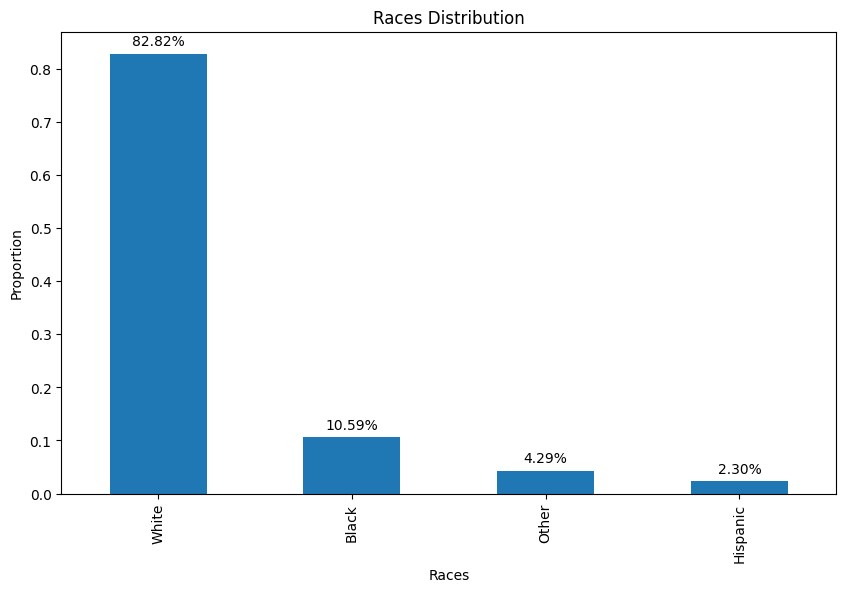

In [20]:
# Basic Summaries: 1. Races distribution
race_mapping = {
    0: 'Unknown',
    1: 'White',
    2: 'Black',
    3: 'Other',
    4: 'Asian',
    5: 'Hispanic',
    6: 'North American Native'
} # Comes from resource: https://www.cms.gov/research-statistics-data-and-systems/files-for-order/identifiabledatafiles/downloads/sasiddenom.pdf
beneficiary_combined_df['BENE_RACE_LABEL'] = beneficiary_df['BENE_RACE_CD'].map(race_mapping)

race_counts =beneficiary_combined_df["BENE_RACE_LABEL"].value_counts(normalize=True)
ax = race_counts.plot(kind='bar', figsize=(10, 6))

plt.title("Races Distribution")
plt.xlabel("Races")
plt.ylabel("Proportion")

for i, value in enumerate(race_counts):
  plt.text(i, value + 0.01, f'{value:.2%}', ha='center', va='bottom', fontsize=10)

plt.show()

0	Unknown
1	White
2	Black
3	Other
4	Asian
5	Hispanic
6	North American Native

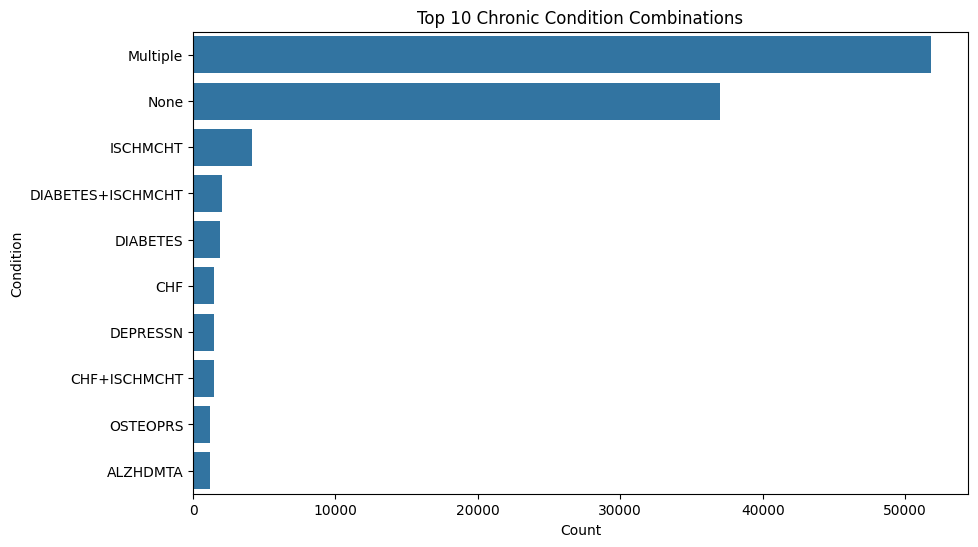

In [40]:
# Basic summary: 2. What is the most common chronic illness combination?

beneficiary_combined_df[beneficiary_combined_df["chronic_condition"]!="None"]["chronic_condition"].value_counts().head(10) # Excluded the None value

plt.figure(figsize=(10,6))
sns.countplot(y='chronic_condition', data=beneficiary_combined_df, order=beneficiary_combined_df['chronic_condition'].value_counts().head(10).index)
plt.title("Top 10 Chronic Condition Combinations")
plt.xlabel("Count")
plt.ylabel("Condition")
plt.show()

In [28]:
# Basic summary: 3. What is the chronic illness combination which has the highest cost
total_cost_by_condition = merged_df.groupby("chronic_condition")["CLM_PMT_AMT"].sum().sort_values(ascending=False)
print(total_cost_by_condition[:10])

chronic_condition
Multiple             182385300.0
None                   7755010.0
ISCHMCHT               4334760.0
DIABETES+ISCHMCHT      3100730.0
DIABETES               2360100.0
CHF+ISCHMCHT           1991090.0
DEPRESSN               1466400.0
CHF                    1231370.0
DEPRESSN+ISCHMCHT      1154950.0
OSTEOPRS               1088970.0
Name: CLM_PMT_AMT, dtype: float64


In [27]:
# Basic summary: 4. Which chronic illness combination has the highest cost per member?
mean_cost_by_condition = merged_df.groupby("chronic_condition")["CLM_PMT_AMT"].mean().sort_values(ascending=False)
print(mean_cost_by_condition[:10])

chronic_condition
CHRNKIDN+STRKETIA    453.055556
CHRNKIDN+DIABETES    339.135338
CHRNKIDN             332.031144
CNCR+STRKETIA        315.000000
Multiple             301.633317
CNCR                 289.046275
ALZHDMTA+CHRNKIDN    284.185464
COPD+STRKETIA        274.545455
OSTEOPRS+STRKETIA    271.964286
CNCR+OSTEOPRS        269.880240
Name: CLM_PMT_AMT, dtype: float64


In [42]:
# Verify the results
cost_summary = merged_df.groupby('chronic_condition')['CLM_PMT_AMT'].agg(['sum','mean','count']).sort_values('sum', ascending=False)
print("Top Chronic Conditions by Total Cost:")
display(cost_summary.head())

print("Top Chronic Conditions by Cost Per Member:")
display(cost_summary.sort_values('mean', ascending=False).head())

Top Chronic Conditions by Total Cost:


,sum,mean,count
chronic_condition,,,
Multiple,182385300.0,301.633317,604659
None,7755010.0,216.408818,35835
ISCHMCHT,4334760.0,224.030182,19349
DIABETES+ISCHMCHT,3100730.0,217.244448,14273
DIABETES,2360100.0,210.798499,11196


Top Chronic Conditions by Cost Per Member:


,sum,mean,count
chronic_condition,,,
CHRNKIDN+STRKETIA,16310.0,453.055556,36
CHRNKIDN+DIABETES,631470.0,339.135338,1862
CHRNKIDN,490410.0,332.031144,1477
CNCR+STRKETIA,6300.0,315.000000,20
Multiple,182385300.0,301.633317,604659


## Benchmarking Providers

The aim here is to understand the distribution of cost across providers treating members with these chronic illnesses. Benchmarking providers across types of care is often a helpful starting point to begin working with areas of excessive cost.


· For each provider (use AT_PHYSN_NPI) & chronic illness, calculate the cost per member.

· For each chronic illness combination, represent the distribution of costs per provider.

· How does this change if we filter out cases where a given Chronic Illness & Provider NPI combination only has one member?

· Which providers are consistently expensive across chronic illnesses they treat?

In [47]:
# For each provider (use AT_PHYSN_NPI) & chronic illness, calculate the cost per member.
provider_summary = merged_df.groupby(["AT_PHYSN_NPI", "chronic_condition"])["CLM_PMT_AMT"].agg(["mean", "count"]).reset_index()


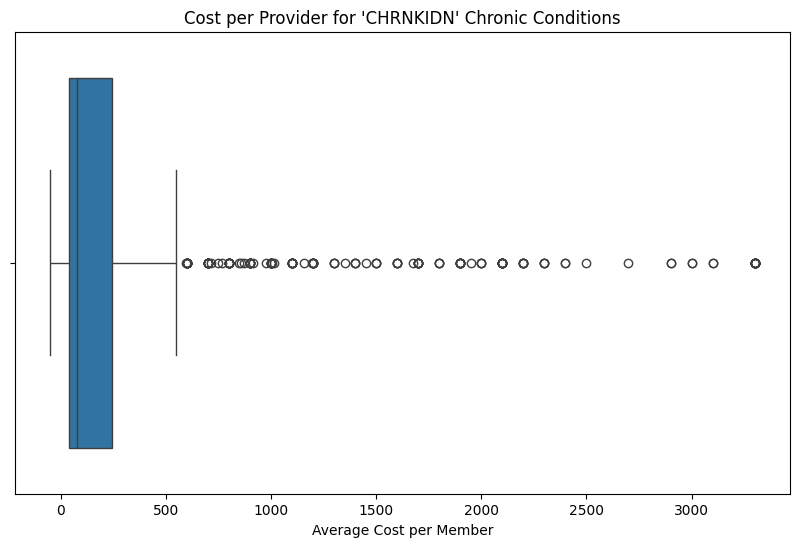

In [51]:
chronic_condition = "CHRNKIDN"
plt.figure(figsize=(10,6))
sns.boxplot(data=provider_summary[provider_summary['chronic_condition']==chronic_condition], x='mean')
plt.title(f"Cost per Provider for '{chronic_condition}' Chronic Conditions")
plt.xlabel("Average Cost per Member")
plt.show()

In [55]:
# Count how many combination which only have one patient
len(provider_summary[provider_summary['count'] == 1])


130583

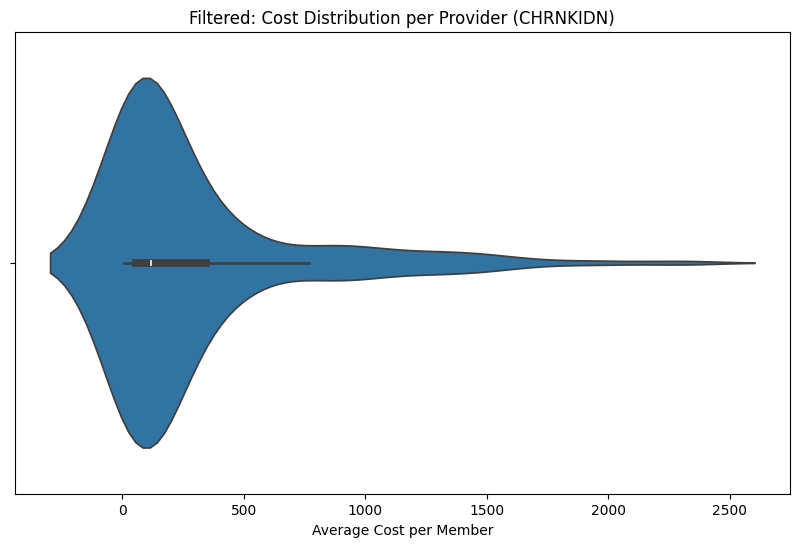

In [56]:
provider_summary_filtered = provider_summary[provider_summary['count'] > 1]
plt.figure(figsize=(10,6))
sns.violinplot(data=provider_summary_filtered[provider_summary_filtered['chronic_condition'] == chronic_condition], x='mean')
plt.title(f'Filtered: Cost Distribution per Provider ({chronic_condition})')
plt.xlabel('Average Cost per Member')
plt.show()

In [59]:
# Which providers are consistently expensive across chronic illnesses they treat?
expensive_providers = provider_summary_filtered.groupby('AT_PHYSN_NPI')['mean'].mean().sort_values(ascending=False)
print(expensive_providers.head(10))

AT_PHYSN_NPI
2.450785e+09    3300.0
5.353246e+09    3250.0
9.331308e+09    3200.0
2.135191e+09    3000.0
6.524443e+08    3000.0
1.508153e+08    2850.0
3.534823e+09    2650.0
4.342928e+09    2650.0
8.342428e+09    2650.0
5.274544e+08    2650.0
Name: mean, dtype: float64
